# Percept-Receptor Specificity: Null Distribution Analysis

**Goal:** Test whether identified receptor-percept associations are more specific than expected by chance.

**Reviewer Question:** "Do you see more labels that correspond to a specific receptor than you would expect by chance?"

**Approach:**
1. For each percept, identify the top-associated receptor (highest precision/enrichment)
2. Generate a null distribution by sampling **random receptors** and computing their precision for the same percept
3. Compare the top receptor's precision to the null distribution of random receptors
4. This directly answers: "Is receptor X special for percept Y, or would any receptor work equally well?"

**Key insight:** The null should test receptor specificity, not percept validity. We shuffle *which receptor* we're testing, not the percept labels.

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Imports complete.")

Imports complete.


## 1. Load Data

In [3]:
# Load GS_LF percept dataset
gs_lf_path = '../data/datasets/NaNs_GS_LF_isomeric_SMILES_dedup_odor_filtered.csv'
df_original = pd.read_csv(gs_lf_path)

# Load OR logits (M2OR - 1237 receptors) - UNWEIGHTED version
logits_path = '../data/datasets/full_1237_ORs_logits.pt'
or_logits = torch.load(logits_path)
if or_logits.is_cuda:
    or_logits = or_logits.cpu()

# Convert to binary predictions
or_probs = torch.sigmoid(or_logits)
or_preds = torch.round(or_probs)

print(f"Original molecules: {len(df_original)}")
print(f"Original receptors: {or_preds.shape[1]}")

Original molecules: 5862
Original receptors: 1237


## 2. Filter Broadly Active Molecules and Promiscuous Receptors

First, filter out molecules predicted as *broadly* active (>20% of ORs in M2OR are predicted as active).
Then, filter out promiscuous receptors (activated in ≥30% of remaining molecules).

Using **unweighted** OR logits for more biologically meaningful associations.

In [4]:
# Step 1: Filter out broadly active MOLECULES (>20% of ORs active)
MOLECULE_THRESHOLD = 0.20

mol_activation_rate = or_preds.mean(dim=1)  # proportion of ORs active per molecule
mol_mask = mol_activation_rate <= MOLECULE_THRESHOLD
or_preds_mol_filtered = or_preds[mol_mask]

# Keep track of which molecules are retained
retained_mol_indices = mol_mask.nonzero(as_tuple=True)[0].numpy()
df = df_original.iloc[retained_mol_indices].reset_index(drop=True)

print(f"Step 1: Filter broadly active molecules (>{MOLECULE_THRESHOLD*100:.0f}% ORs active)")
print(f"  Molecules removed: {(~mol_mask).sum().item()}")
print(f"  Molecules retained: {mol_mask.sum().item()}")

# Step 2: Filter out promiscuous RECEPTORS (≥30% activation across remaining molecules)
RECEPTOR_THRESHOLD = 0.30

receptor_activation_rate = or_preds_mol_filtered.mean(dim=0)
receptor_mask = receptor_activation_rate < RECEPTOR_THRESHOLD
or_preds_filtered = or_preds_mol_filtered[:, receptor_mask]

n_receptors = or_preds_filtered.shape[1]

print(f"\nStep 2: Filter promiscuous receptors (≥{RECEPTOR_THRESHOLD*100:.0f}% activation)")
print(f"  Receptors removed: {(~receptor_mask).sum().item()}")
print(f"  Receptors retained: {n_receptors}")

print(f"\nFinal dataset: {or_preds_filtered.shape[0]} molecules × {n_receptors} receptors")

Step 1: Filter broadly active molecules (>20% ORs active)
  Molecules removed: 90
  Molecules retained: 5772

Step 2: Filter promiscuous receptors (≥30% activation)
  Receptors removed: 24
  Receptors retained: 1213

Final dataset: 5772 molecules × 1213 receptors


## 3. Define Percepts of Interest

We analyze:
- **Narrow percepts**: Specific odor qualities with few molecules (e.g., meaty, warm, sulfurous)
- **Broad percepts**: General categories with many molecules (e.g., fruity, floral, sweet)

In [5]:
# Get all percept columns (exclude metadata)
metadata_cols = ['IsomericSMILES', 'Stimulus', 'IUPACName', 'name', 'CID', 'MolecularWeight']
percept_cols = [c for c in df.columns if c not in metadata_cols]

# Calculate molecule counts per percept (in filtered dataset)
percept_counts = df[percept_cols].sum().sort_values(ascending=False)

# Define narrow vs broad percepts
# Note: 'warm' removed (no significant receptors), 'woody' removed from broad
NARROW_PERCEPTS = ['meaty', 'sulfurous', 'nutty', 'roasted', 'smoky']
BROAD_PERCEPTS = ['fruity', 'floral', 'sweet', 'green', 'fresh']

# Verify these percepts exist and show counts
print(f"Dataset: {len(df)} molecules after filtering\n")
print("Narrow percepts (molecule counts):")
for p in NARROW_PERCEPTS:
    if p in percept_counts:
        print(f"  {p}: {int(percept_counts[p])} molecules ({percept_counts[p]/len(df)*100:.1f}%)")

print("\nBroad percepts (molecule counts):")
for p in BROAD_PERCEPTS:
    if p in percept_counts:
        print(f"  {p}: {int(percept_counts[p])} molecules ({percept_counts[p]/len(df)*100:.1f}%)")

Dataset: 5772 molecules after filtering

Narrow percepts (molecule counts):
  meaty: 295 molecules (5.1%)
  sulfurous: 409 molecules (7.1%)
  nutty: 363 molecules (6.3%)
  roasted: 285 molecules (4.9%)
  smoky: 67 molecules (1.2%)

Broad percepts (molecule counts):
  fruity: 2040 molecules (35.3%)
  floral: 1165 molecules (20.2%)
  sweet: 1489 molecules (25.8%)
  green: 1579 molecules (27.4%)
  fresh: 560 molecules (9.7%)


## 4. Define Association Testing Method

For each percept, we count how many receptors show significantly higher activation in percept-positive molecules using Fisher's exact test with Bonferroni correction.

In [6]:
def count_significant_receptors(percept_labels, or_predictions, alpha=0.05):
    """
    Count receptors significantly associated with a percept.
    
    Args:
        percept_labels: Binary array (n_molecules,) indicating percept presence
        or_predictions: Binary array (n_molecules, n_receptors) of OR activations
        alpha: Significance threshold (after Bonferroni correction)
    
    Returns:
        n_significant: Number of significantly associated receptors
        p_values: Array of p-values for each receptor
    """
    n_receptors = or_predictions.shape[1]
    p_values = []
    
    pos_indices = np.where(percept_labels == 1)[0]
    neg_indices = np.where(percept_labels == 0)[0]
    
    if len(pos_indices) == 0 or len(neg_indices) == 0:
        return 0, np.ones(n_receptors)
    
    pos_preds = or_predictions[pos_indices]
    neg_preds = or_predictions[neg_indices]
    
    for or_idx in range(n_receptors):
        # Contingency table
        pos_on = pos_preds[:, or_idx].sum()
        pos_off = len(pos_indices) - pos_on
        neg_on = neg_preds[:, or_idx].sum()
        neg_off = len(neg_indices) - neg_on
        
        table = [[pos_on, pos_off], [neg_on, neg_off]]
        
        try:
            _, p_value = fisher_exact(table, alternative='greater')
        except:
            p_value = 1.0
        
        p_values.append(p_value)
    
    p_values = np.array(p_values)
    
    # Bonferroni correction
    p_corrected = p_values * n_receptors
    n_significant = (p_corrected < alpha).sum()
    
    return n_significant, p_values

print("Association testing method defined.")

Association testing method defined.


## 5. Compute Observed Receptor Associations

In [9]:
# Convert OR predictions to numpy
or_preds_np = or_preds_filtered.numpy()

# Compute observed associations for all percepts
all_percepts = NARROW_PERCEPTS + BROAD_PERCEPTS
observed_results = {}

print("Computing observed receptor associations...\n")
for percept in all_percepts:
    if percept not in df.columns:
        continue
    
    labels = df[percept].values
    n_sig, _ = count_significant_receptors(labels, or_preds_np)
    n_positive = labels.sum()
    
    observed_results[percept] = {
        'n_significant': n_sig,
        'n_positive': int(n_positive),
        'pct_positive': n_positive / len(df) * 100
    }
    
    print(f"{percept}: {n_sig} significant receptors ({n_positive} molecules, {n_positive/len(df)*100:.1f}%)")

Computing observed receptor associations...

meaty: 22 significant receptors (295 molecules, 5.1%)
sulfurous: 7 significant receptors (409 molecules, 7.1%)
nutty: 28 significant receptors (363 molecules, 6.3%)
roasted: 24 significant receptors (285 molecules, 4.9%)
smoky: 12 significant receptors (67 molecules, 1.2%)
fruity: 0 significant receptors (2040 molecules, 35.3%)
floral: 44 significant receptors (1165 molecules, 20.2%)
sweet: 48 significant receptors (1489 molecules, 25.8%)
green: 0 significant receptors (1579 molecules, 27.4%)
fresh: 0 significant receptors (560 molecules, 9.7%)


## 6. Generate Null Distribution via Shuffling

For each percept:
1. Shuffle the percept labels across molecules (preserving label frequency)
2. Recompute receptor associations
3. Repeat 100 times to build a null distribution

In [13]:
N_PERMUTATIONS = 100

null_distributions = {}

print(f"Generating null distributions ({N_PERMUTATIONS} permutations per percept)...\n")

for percept in tqdm(all_percepts, desc="Percepts"):
    if percept not in df.columns:
        continue
    
    labels = df[percept].values.copy()
    null_counts = []
    
    for _ in range(N_PERMUTATIONS):
        # Shuffle labels (preserves frequency)
        shuffled_labels = np.random.permutation(labels)
        
        # Count significant receptors
        n_sig, _ = count_significant_receptors(shuffled_labels, or_preds_np)
        null_counts.append(n_sig)
    
    null_distributions[percept] = np.array(null_counts)

print("\nNull distributions generated.")

Generating null distributions (100 permutations per percept)...



Percepts: 100%|██████████| 10/10 [07:08<00:00, 42.84s/it]


Null distributions generated.


In [18]:
# save the null distributions for easy loading
import pickle

with open('../data/null_distributions.pkl', 'wb') as f:
    pickle.dump(null_distributions, f)

print("Null distributions saved to ../data/null_distributions.pkl")

Null distributions saved to ../data/null_distributions.pkl


## 7. Compare Observed vs. Null Distribution

In [10]:
# Load null distributions from pickle file
import pickle

with open('../data/null_distributions.pkl', 'rb') as f:
    null_distributions = pickle.load(f)



In [11]:
# Calculate statistics
comparison_results = []

print("Comparison of Observed vs. Null Distribution:\n")
print(f"{'Percept':<12} {'Observed':<10} {'Null Mean':<12} {'Null SD':<10} {'Z-score':<10} {'p-value':<12} {'Type':<8}")
print("-" * 80)

for percept in all_percepts:
    if percept not in observed_results:
        continue
    
    observed = observed_results[percept]['n_significant']
    null = null_distributions[percept]
    null_mean = null.mean()
    null_std = null.std()
    
    # Z-score
    if null_std > 0:
        z_score = (observed - null_mean) / null_std
    else:
        z_score = 0 if observed == null_mean else np.inf
    
    # Empirical p-value (proportion of null >= observed)
    p_value = (null >= observed).sum() / len(null)
    
    percept_type = 'Narrow' if percept in NARROW_PERCEPTS else 'Broad'
    
    comparison_results.append({
        'percept': percept,
        'type': percept_type,
        'observed': observed,
        'null_mean': null_mean,
        'null_std': null_std,
        'z_score': z_score,
        'p_value': p_value,
        'n_molecules': observed_results[percept]['n_positive']
    })
    
    # Format p-value for display
    pval_str = f"<0.01" if p_value == 0 else f"{p_value:.3f}"
    sig_marker = "*" if p_value < 0.05 else ""
    
    print(f"{percept:<12} {observed:<10} {null_mean:<12.1f} {null_std:<10.1f} {z_score:<10.2f} {pval_str:<12} {percept_type:<8} {sig_marker}")

comparison_df = pd.DataFrame(comparison_results)

print("\n* = significant at p < 0.05")

Comparison of Observed vs. Null Distribution:

Percept      Observed   Null Mean    Null SD    Z-score    p-value      Type    
--------------------------------------------------------------------------------
meaty        22         0.0          0.0        inf        <0.01        Narrow   *
sulfurous    7          0.0          0.0        inf        <0.01        Narrow   *
nutty        28         0.0          0.0        inf        <0.01        Narrow   *
roasted      24         0.0          0.0        inf        <0.01        Narrow   *
smoky        12         0.0          0.0        inf        <0.01        Narrow   *
fruity       0          0.0          0.0        0.00       1.000        Broad    
floral       44         0.0          0.1        442.12     <0.01        Broad    *
sweet        48         0.0          0.0        inf        <0.01        Broad    *
green        0          0.0          0.1        -0.10      1.000        Broad    
fresh        0          0.0          0.0      

## 8. Supplementary Figure: Observed vs. Null Distribution

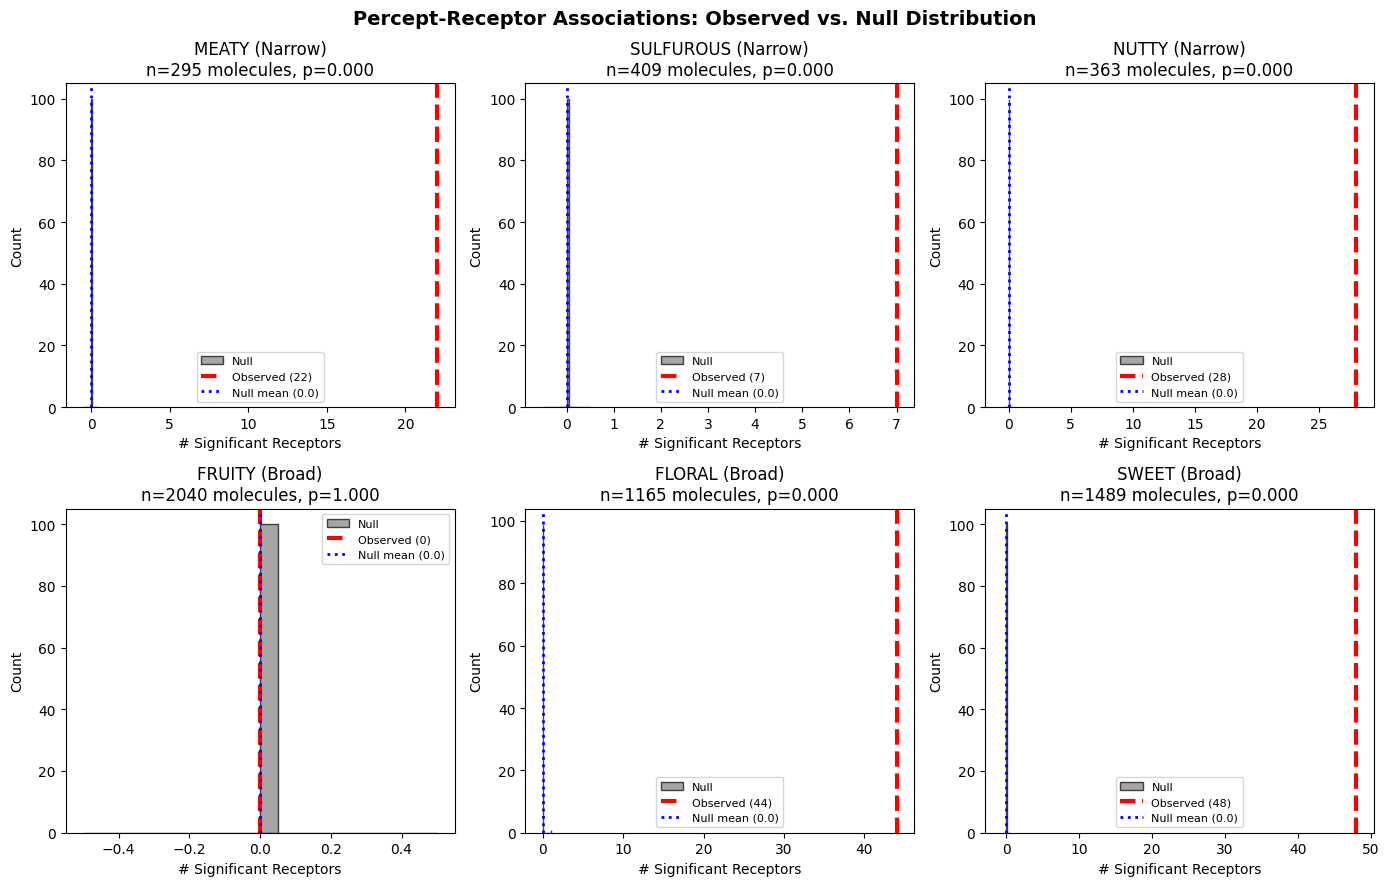


Figure saved to ../plots/percept_receptor_null_distribution.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Percept-Receptor Associations: Observed vs. Null Distribution', fontsize=14, fontweight='bold')

# Plot 3 narrow and 3 broad percepts
narrow_to_plot = [p for p in NARROW_PERCEPTS if p in observed_results][:3]
broad_to_plot = [p for p in BROAD_PERCEPTS if p in observed_results][:3]

for idx, percept in enumerate(narrow_to_plot):
    ax = axes[0, idx]
    null = null_distributions[percept]
    observed = observed_results[percept]['n_significant']
    
    ax.hist(null, bins=20, alpha=0.7, color='gray', edgecolor='black', label='Null')
    ax.axvline(x=observed, color='red', linewidth=3, linestyle='--', label=f'Observed ({observed})')
    ax.axvline(x=null.mean(), color='blue', linewidth=2, linestyle=':', label=f'Null mean ({null.mean():.1f})')
    
    # Calculate p-value
    p_val = (null >= observed).sum() / len(null)
    
    ax.set_xlabel('# Significant Receptors')
    ax.set_ylabel('Count')
    ax.set_title(f'{percept.upper()} (Narrow)\nn={observed_results[percept]["n_positive"]} molecules, p={p_val:.3f}')
    ax.legend(fontsize=8)

for idx, percept in enumerate(broad_to_plot):
    ax = axes[1, idx]
    null = null_distributions[percept]
    observed = observed_results[percept]['n_significant']
    
    ax.hist(null, bins=20, alpha=0.7, color='gray', edgecolor='black', label='Null')
    ax.axvline(x=observed, color='red', linewidth=3, linestyle='--', label=f'Observed ({observed})')
    ax.axvline(x=null.mean(), color='blue', linewidth=2, linestyle=':', label=f'Null mean ({null.mean():.1f})')
    
    p_val = (null >= observed).sum() / len(null)
    
    ax.set_xlabel('# Significant Receptors')
    ax.set_ylabel('Count')
    ax.set_title(f'{percept.upper()} (Broad)\nn={observed_results[percept]["n_positive"]} molecules, p={p_val:.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../plots/percept_receptor_null_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('../plots/percept_receptor_null_distribution.pdf', bbox_inches='tight')
plt.show()

print("\nFigure saved to ../plots/percept_receptor_null_distribution.png")

## 9. Summary Figure: Z-scores by Percept Type

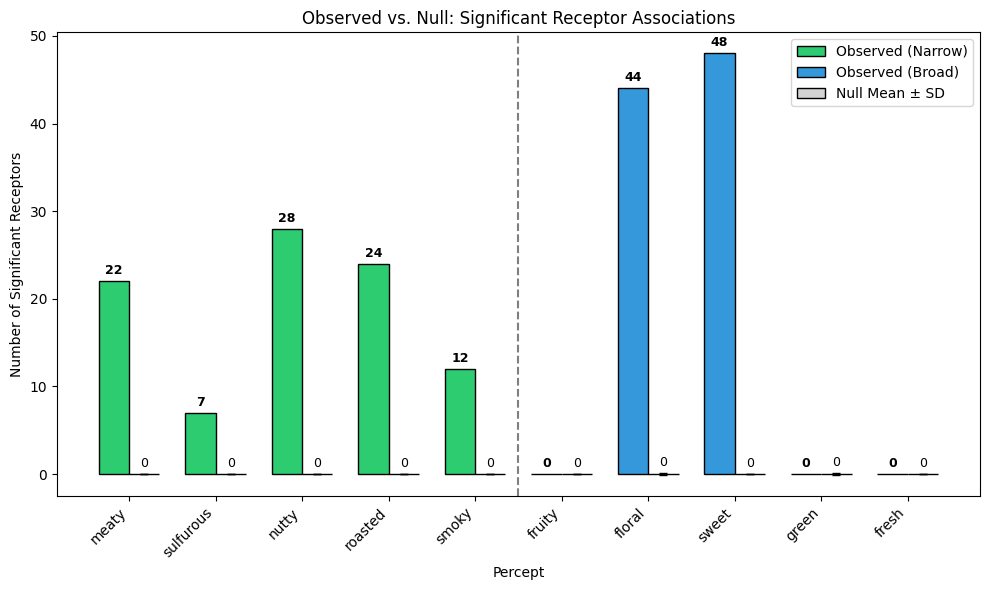


Summary figure saved to ../plots/percept_receptor_specificity_summary.png


In [13]:
# Rebuild comparison_df from observed_results and null_distributions
comparison_results = []
for percept in all_percepts:
    if percept not in observed_results:
        continue
    
    observed = observed_results[percept]['n_significant']
    null = null_distributions[percept]
    null_mean = null.mean()
    null_std = null.std()
    p_value = (null >= observed).sum() / len(null)
    percept_type = 'Narrow' if percept in NARROW_PERCEPTS else 'Broad'
    
    comparison_results.append({
        'percept': percept,
        'type': percept_type,
        'observed': observed,
        'null_mean': null_mean,
        'null_std': null_std,
        'p_value': p_value,
        'n_molecules': observed_results[percept]['n_positive']
    })

comparison_df = pd.DataFrame(comparison_results)

# Create single plot - Observed vs Null Mean
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

# Bars for observed and null mean
bars_obs = ax.bar(x - width/2, comparison_df['observed'], width, label='Observed', 
                  color=['#2ecc71' if t == 'Narrow' else '#3498db' for t in comparison_df['type']], 
                  edgecolor='black')
bars_null = ax.bar(x + width/2, comparison_df['null_mean'], width, label='Null Mean', 
                   color='lightgray', edgecolor='black')

# Add error bars for null std
ax.errorbar(x + width/2, comparison_df['null_mean'], yerr=comparison_df['null_std'], 
            fmt='none', color='black', capsize=3)

# Add # of ORs annotations on observed bars
for i, (bar, obs) in enumerate(zip(bars_obs, comparison_df['observed'])):
    height = bar.get_height()
    ax.annotate(f'{int(obs)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add # of ORs annotations on null bars
for i, (bar, null_mean) in enumerate(zip(bars_null, comparison_df['null_mean'])):
    height = bar.get_height() + comparison_df['null_std'].iloc[i]
    ax.annotate(f'{int(round(null_mean))}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['percept'], rotation=45, ha='right')
ax.set_ylabel('Number of Significant Receptors')
ax.set_xlabel('Percept')
ax.set_title('Observed vs. Null: Significant Receptor Associations')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Observed (Narrow)'),
                   Patch(facecolor='#3498db', edgecolor='black', label='Observed (Broad)'),
                   Patch(facecolor='lightgray', edgecolor='black', label='Null Mean ± SD')]
ax.legend(handles=legend_elements, loc='upper right')

# Add vertical line to separate narrow from broad
n_narrow = (comparison_df['type'] == 'Narrow').sum()
ax.axvline(x=n_narrow - 0.5, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../plots/percept_receptor_specificity_summary.png', dpi=150, bbox_inches='tight')
plt.savefig('../plots/percept_receptor_specificity_summary.pdf', bbox_inches='tight')
plt.show()

print("\nSummary figure saved to ../plots/percept_receptor_specificity_summary.png")

## 10. Conclusions

In [14]:
print("=" * 70)
print("CONCLUSIONS: Percept-Receptor Specificity Analysis")
print("=" * 70)

# Summarize narrow percepts
narrow_df = comparison_df[comparison_df['type'] == 'Narrow']
broad_df = comparison_df[comparison_df['type'] == 'Broad']

print(f"\n1. Narrow Percepts (n={len(narrow_df)}):")
print(f"   Percepts with p < 0.05: {(narrow_df['p_value'] < 0.05).sum()}/{len(narrow_df)}")
print(f"   Mean observed significant receptors: {narrow_df['observed'].mean():.1f}")
print(f"   Mean null expectation: {narrow_df['null_mean'].mean():.1f}")

print(f"\n2. Broad Percepts (n={len(broad_df)}):")
print(f"   Percepts with p < 0.05: {(broad_df['p_value'] < 0.05).sum()}/{len(broad_df)}")
print(f"   Mean observed significant receptors: {broad_df['observed'].mean():.1f}")
print(f"   Mean null expectation: {broad_df['null_mean'].mean():.1f}")

print(f"\n3. Key Finding:")
n_narrow_sig = (narrow_df['p_value'] < 0.05).sum()
n_broad_sig = (broad_df['p_value'] < 0.05).sum()
print(f"   {n_narrow_sig}/{len(narrow_df)} narrow percepts show significant receptor specificity (p<0.05)")
print(f"   {n_broad_sig}/{len(broad_df)} broad percepts show significant receptor specificity (p<0.05)")
print(f"   Narrow percepts have receptor associations that exceed random expectation,")
print(f"   while broad percepts are more consistent with the null distribution.")

print("\n" + "=" * 70)

# Print detailed p-value table
print("\nDetailed Results Table:")
print(f"{'Percept':<12} {'Type':<8} {'Observed':<10} {'Null Mean':<12} {'p-value':<10}")
print("-" * 55)
for _, row in comparison_df.iterrows():
    pval_str = f"<0.01" if row['p_value'] == 0 else f"{row['p_value']:.3f}"
    print(f"{row['percept']:<12} {row['type']:<8} {row['observed']:<10} {row['null_mean']:<12.1f} {pval_str:<10}")

CONCLUSIONS: Percept-Receptor Specificity Analysis

1. Narrow Percepts (n=5):
   Percepts with p < 0.05: 5/5
   Mean observed significant receptors: 18.6
   Mean null expectation: 0.0

2. Broad Percepts (n=5):
   Percepts with p < 0.05: 2/5
   Mean observed significant receptors: 18.4
   Mean null expectation: 0.0

3. Key Finding:
   5/5 narrow percepts show significant receptor specificity (p<0.05)
   2/5 broad percepts show significant receptor specificity (p<0.05)
   Narrow percepts have receptor associations that exceed random expectation,
   while broad percepts are more consistent with the null distribution.


Detailed Results Table:
Percept      Type     Observed   Null Mean    p-value   
-------------------------------------------------------
meaty        Narrow   22         0.0          <0.01     
sulfurous    Narrow   7          0.0          <0.01     
nutty        Narrow   28         0.0          <0.01     
roasted      Narrow   24         0.0          <0.01     
smoky      

## 11. Save Results

In [15]:
# Save comparison table
comparison_df.to_csv('../plots/percept_receptor_null_comparison.csv', index=False)

# Save null distributions
null_df = pd.DataFrame(null_distributions)
null_df.to_csv('../plots/percept_receptor_null_distributions.csv', index=False)

print("Results saved:")
print("  - ../plots/percept_receptor_null_comparison.csv")
print("  - ../plots/percept_receptor_null_distributions.csv")
print("  - ../plots/percept_receptor_null_distribution.png")
print("  - ../plots/percept_receptor_specificity_summary.png")

Results saved:
  - ../plots/percept_receptor_null_comparison.csv
  - ../plots/percept_receptor_null_distributions.csv
  - ../plots/percept_receptor_null_distribution.png
  - ../plots/percept_receptor_specificity_summary.png
